## Semiconductor Wafer Defect Detection using Computer Vision and Machine Learning

## Problem Statement

Semiconductor manufacturing requires automated inspection systems to detect defects on wafer surfaces. Manual inspection of wafer maps is time-consuming and prone to human error. Therefore, automated inspection systems are widely used in semiconductor manufacturing to detect and classify defect patterns efficiently. The objective of this project is to develop a computer vision-based pipeline that can automatically detect and classify semiconductor wafer defect patterns. The proposed approach uses classical image processing techniques and machine learning algorithms to analyze wafer maps and identify different types of defects.

## Dataset Description
This project uses a subset of the WM-811K Wafer Map Dataset, a publicly available dataset from Kaggle, widely used in semiconductor defect detection research.
Each wafer map is labeled with a defect pattern type. For this project, four defect categories were selected:

1. Center
2. Donut
3. Edge-Ring
4. Scratch

The dataset is divided into training, validation, and testing sets, enabling the development and evaluation of machine learning models for wafer defect classification.

## Import required libraries

In [46]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Load dataset

In [47]:
train_path = r"C:\Users\SUGANYA\Downloads\WM811K\train_data.pkl"
val_path   = r"C:\Users\SUGANYA\Downloads\WM811K\val_data.pkl"
test_path  = r"C:\Users\SUGANYA\Downloads\WM811K\test_data.pkl"

train_df = pd.read_pickle(train_path)
val_df   = pd.read_pickle(val_path)
test_df  = pd.read_pickle(test_path)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(49798, 3)
(12450, 3)
(12450, 3)


In [48]:
train_df.head()

,waferMap,failureType,failureCode
43809,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 255...",none,8
14410,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",none,8
2428,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128,...",none,8
50938,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 255, 128, 128,...",none,8
45657,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Edge-Ring,3


In [49]:
train_df['failureType'].value_counts()

failureType
none         29383
Edge-Ring     7744
Edge-Loc      4151
Center        3435
Loc           2874
Scratch        955
Random         693
Donut          444
Near-full      119
Name: count, dtype: int64

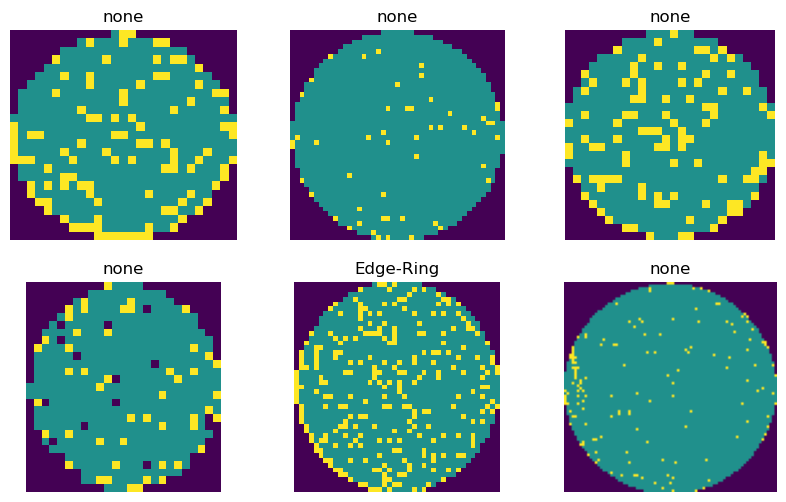

In [50]:
plt.figure(figsize=(10,6))

for i in range(6):

    wafer = train_df.iloc[i]['waferMap']

    plt.subplot(2,3,i+1)
    plt.imshow(wafer)
    plt.title(train_df.iloc[i]['failureType'])
    plt.axis("off")

plt.show()

In [51]:
train_df = train_df[train_df['failureType'] != 'none']
val_df   = val_df[val_df['failureType'] != 'none']
test_df  = test_df[test_df['failureType'] != 'none']

In [52]:
selected_classes = ['Center','Donut','Edge-Ring','Scratch']

train_df = train_df[train_df['failureType'].isin(selected_classes)]
val_df   = val_df[val_df['failureType'].isin(selected_classes)]
test_df  = test_df[test_df['failureType'].isin(selected_classes)]

### Balance dataset

In [53]:
min_samples = train_df['failureType'].value_counts().min()

train_df = train_df.groupby('failureType').sample(n=min_samples, random_state=42)

In [54]:
train_df['failureType'].value_counts()

failureType
Center       444
Donut        444
Edge-Ring    444
Scratch      444
Name: count, dtype: int64

### Convert wafer map to image

In [55]:
def preprocess_wafer(wafer):

    wafer = np.array(wafer)

    wafer = cv2.resize(wafer,(128,128))

    wafer = wafer.astype(np.uint8)

    return wafer

In [56]:
train_images = []
train_labels = []

for i in range(len(train_df)):

    wafer = preprocess_wafer(train_df.iloc[i]['waferMap'])

    label = train_df.iloc[i]['failureType']

    train_images.append(wafer)
    train_labels.append(label)

train_images = np.array(train_images)
train_labels = np.array(train_labels)

print(train_images.shape)

(1776, 128, 128)


In [57]:
val_images = []
val_labels = []

for i in range(len(val_df)):

    wafer = preprocess_wafer(val_df.iloc[i]['waferMap'])

    label = val_df.iloc[i]['failureType']

    val_images.append(wafer)
    val_labels.append(label)

val_images = np.array(val_images)
val_labels = np.array(val_labels)

In [58]:
test_images = []
test_labels = []

for i in range(len(test_df)):

    wafer = preprocess_wafer(test_df.iloc[i]['waferMap'])

    label = test_df.iloc[i]['failureType']

    test_images.append(wafer)
    test_labels.append(label)

test_images = np.array(test_images)
test_labels = np.array(test_labels)

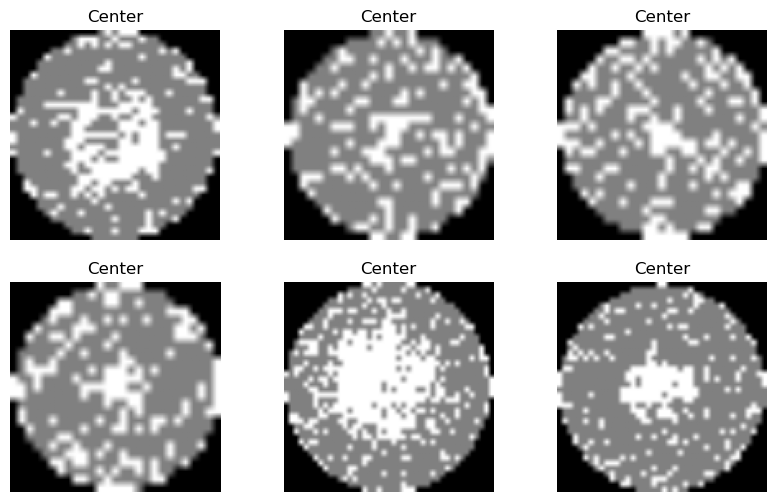

In [59]:
plt.figure(figsize=(10,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(train_images[i], cmap="gray")

    plt.title(train_labels[i])

    plt.axis("off")

plt.show()

### Gaussian filtering

In [60]:
def gaussian_filter(image):

    filtered = cv2.GaussianBlur(image,(5,5),0)

    return filtered

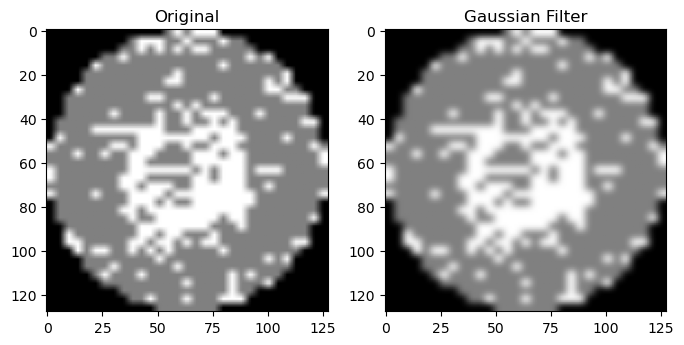

In [61]:
sample = train_images[0]

filtered = gaussian_filter(sample)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(filtered,cmap='gray')
plt.title("Gaussian Filter")

plt.show()

### Edge detection

In [62]:
def detect_edges(image):

    edges = cv2.Canny(image,50,150)

    return edges

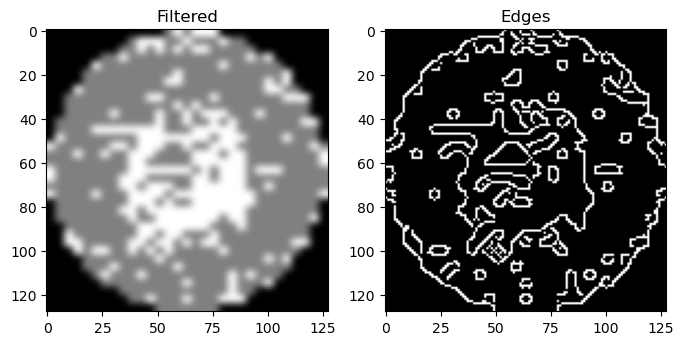

In [63]:
edges = detect_edges(filtered)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(filtered,cmap='gray')
plt.title("Filtered")

plt.subplot(1,2,2)
plt.imshow(edges,cmap='gray')
plt.title("Edges")

plt.show()

### Morphological Operations

In [64]:
def morphology(image):

    kernel = np.ones((3,3),np.uint8)

    morph = cv2.morphologyEx(image,cv2.MORPH_CLOSE,kernel)

    return morph

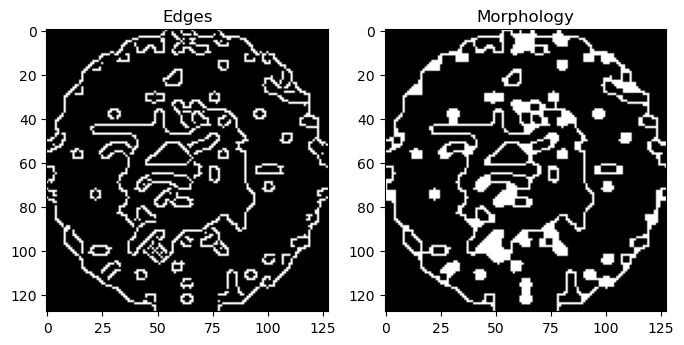

In [65]:
morph = morphology(edges)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(edges,cmap='gray')
plt.title("Edges")

plt.subplot(1,2,2)
plt.imshow(morph,cmap='gray')
plt.title("Morphology")

plt.show()

### HOG Feature Extraction

In [66]:
from skimage.feature import hog

def extract_hog(image):

    features = hog(image,
                   orientations=9,
                   pixels_per_cell=(8,8),
                   cells_per_block=(2,2),
                   block_norm='L2-Hys')

    return features

In [67]:
X_train = []

for img in train_images:

    f = gaussian_filter(img)
    e = detect_edges(f)
    m = morphology(e)

    hog_features = extract_hog(m)

    X_train.append(hog_features)

X_train = np.array(X_train)

y_train = train_labels

### Train SVM Classifier

In [68]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

model = SVC(kernel='rbf')

model.fit(X_train,y_train)


SVC()

### Prepare Validation / Test Data

In [69]:
def build_features(images):

    features = []

    for img in images:

        f = gaussian_filter(img)
        e = detect_edges(f)
        m = morphology(e)

        hog_features = extract_hog(m)

        features.append(hog_features)

    return np.array(features)

### Evaluate model

In [70]:
X_test = build_features(test_images)

X_test = scaler.transform(X_test)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score,classification_report

print("Accuracy:",accuracy_score(test_labels,y_pred))

print(classification_report(test_labels,y_pred))

Accuracy: 0.8498727735368957
              precision    recall  f1-score   support

      Center       0.94      0.67      0.78       859
       Donut       0.52      0.90      0.66       111
   Edge-Ring       0.99      0.92      0.95      1936
     Scratch       0.40      0.92      0.55       238

    accuracy                           0.85      3144
   macro avg       0.71      0.85      0.74      3144
weighted avg       0.92      0.85      0.87      3144



### Confusion matrix

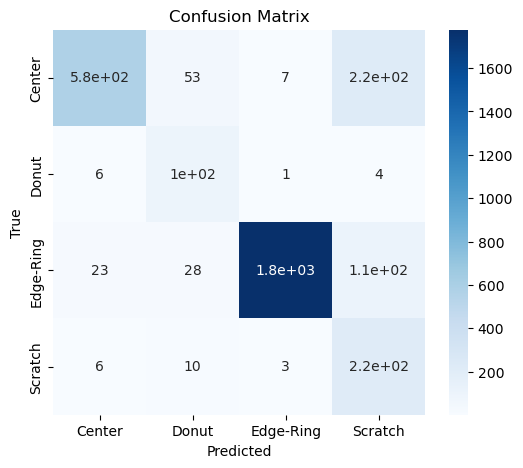

In [71]:
cm = confusion_matrix(test_labels,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            xticklabels=selected_classes,
            yticklabels=selected_classes)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

### Defect Localization Visualization

In [72]:
def localize_defects(image):

    img = image.copy()

    # threshold to detect bright defect pixels
    _, defect_mask = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(defect_mask,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    for cnt in contours:

        if cv2.contourArea(cnt) > 20:

            x,y,w,h = cv2.boundingRect(cnt)

            cv2.rectangle(img_color,(x,y),(x+w,y+h),(255,0,0),2)

    return img_color

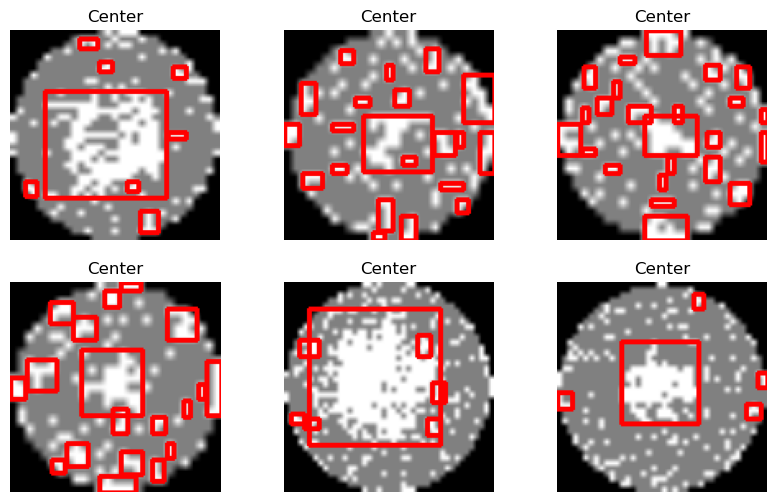

In [73]:
plt.figure(figsize=(10,6))

for i in range(6):

    wafer = train_images[i]

    localized = localize_defects(wafer)

    plt.subplot(2,3,i+1)
    plt.imshow(localized)
    plt.title(train_labels[i])
    plt.axis("off")

plt.show()

## Predicting a test image

In [76]:
sample = test_images[12]

features = build_features([sample])

features_scaled = scaler.transform(features)

prediction = model.predict(features_scaled)

print("Predicted defect:", prediction[0])

Predicted defect: Edge-Ring


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

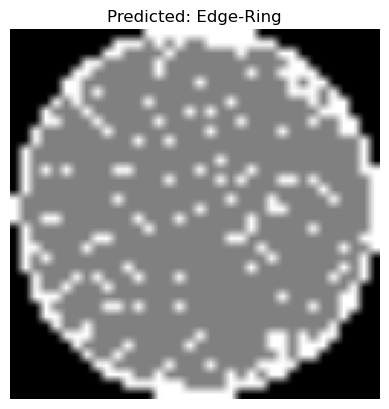

In [77]:
plt.imshow(sample, cmap='gray')
plt.title("Predicted: " + prediction[0])
plt.axis("off")


This project demonstrates a computer vision pipeline for semiconductor wafer defect classification using classical image processing techniques and machine learning models. The approach combines Gaussian filtering, edge detection, HOG feature extraction, and an SVM classifier to identify defect patterns effectively. The SVM classifier trained on HOG features achieved an overall classification accuracy of approximately 85% on the wafer defect dataset. The model performed particularly well on Edge-Ring defects, while Donut and Scratch patterns showed lower precision due to similarity in defect distributions.
